Chapter 33
# K均值聚类
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

大家在使用 Scikit-Learn 聚类算法时，会发现有些算法有 predict() 方法。
也就是说，如图 2 所示，已经训练好的模型，有可能你将全新的数据点分配到确定的簇中。有这种
功能的聚类算法叫做归纳聚类 (inductive clustering)。
本章后文要介绍的 k 均值聚类、高斯混合模型都属于归纳聚类。如图 2 所示，归纳聚类算法也有决
策边界。这就意味着归纳聚类模型具有一定的泛化能力，可以推广到新的、之前未见过的数据。
不具备这种能力的聚类算法叫做非归纳聚类 (non-inductive clustering)。
非归纳聚类只能对训练数据进行聚类，而不能将新数据点添加到已有的模型中进行预测。这意味着
模型在训练时只能学习训练数据的模式，无法用于对新数据点进行簇分配。比如，层次聚类、DBSCAN
聚类都是非归纳聚类。

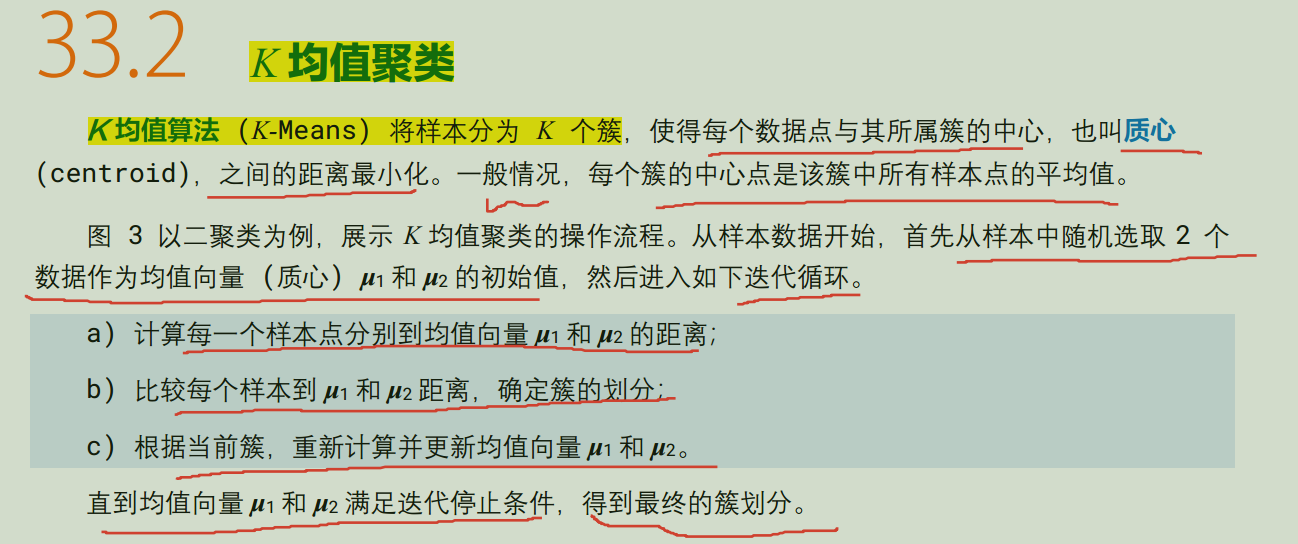

In [2]:
from sklearn import datasets
from sklearn.cluster import KMeans #从 sklearn.cluster 模块导入 K 均值算法对象 KMeans
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap #创建离散颜色映射，以在图表中对不同的离散值进行颜色编码。颜色映射在本例中可视化鸢尾花聚类区域。


# 导入并整理数据

In [3]:
# 导入并整理数据
iris = datasets.load_iris()
X = iris.data[:, :2]

In [5]:
X.shape

(150, 2)

In [6]:
X[:3,]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2]])

## 生成网格化数据

In [10]:
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array) #101*101
# 创建色谱
#每一行为一种颜色
rgb = [[255, 238, 255],
       [219, 238, 244],
       [228, 228, 228]]
rgb = np.array(rgb)/255. #归一化（0-1）
cmap_light = ListedColormap(rgb) #创建离散颜色映射

In [11]:
rgb

array([[1.        , 0.93333333, 1.        ],
       [0.85882353, 0.93333333, 0.95686275],
       [0.89411765, 0.89411765, 0.89411765]])

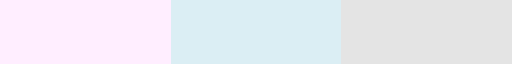

In [12]:
cmap_light # 三种颜色


# 采用KMeans聚类

实例化了一个 KMeans 对象，并指定了要进行的聚类数目。参数 n_clusters 参数就是用来指
定 K 均值聚类算法 K 的值，即希望将数据划分成多少个簇。


执行了 KMeans 聚类算法，拟合模型并预测数据点所属的簇标签。fit_predict(X) 同时拟
合 (fit) 数据并预测 (prefict) 数据点所属的簇标签。
大家也可以用 fit(X).predict(X) 来分两步执行。其中，X 是一个二维数组，表示输入的数
据，每行代表一个数据样本，每列代表一个特征。请大家自行查看返回结果。


In [13]:
# 采用KMeans聚类
kmeans = KMeans(n_clusters=3, n_init = 'auto') #创建一个实例
cluster_labels = kmeans.fit_predict(X) # 训练数据并预测数据

### 预测聚类

按照列进行组合；每一行就是一个数据点；
预测完的结构为 （101*101） * 1

In [14]:
# 预测聚类
Z = kmeans.predict(np.c_[xx1.ravel(), xx2.ravel()])
print(Z.shape)
Z = Z.reshape(xx1.shape) # 重置数组形状
print(Z.shape)

(10201,)
(101, 101)


In [15]:
Z

array([[0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2]], dtype=int32)

In [16]:
Z[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [17]:
Z[52]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [18]:
Z[20]

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

#绘制图像

levels: [0, 1, 2]
centroids: [[5.8        2.7       ]
 [5.00392157 3.40980392]
 [6.82391304 3.07826087]]


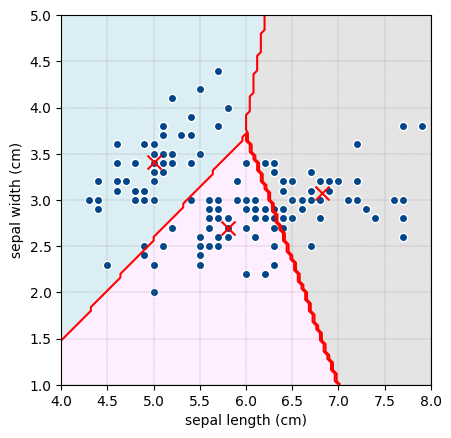

In [19]:
fig, ax = plt.subplots()

# 根据每个点的预测的标签绘制对应的区域
ax.contourf(xx1, xx2, Z, cmap=cmap_light) #用填充等高线可视化聚类区域。
# 原始数据
ax.scatter(x=X[:, 0], y=X[:, 1],
           color=np.array([0, 68, 138])/255.,
           alpha=1.0,
           linewidth = 1, edgecolor=[1,1,1]) #边界颜色为白色
# 绘制决策边界
levels = np.unique(Z).tolist(); # 去重并转为list；判断有几个类别
print(f"levels: {levels}")
# 绘制边界也就是等高线；3个种类
ax.contour(xx1, xx2, Z, levels=levels,colors='r')
#获取 KMeans 聚类算法拟合后得到的聚类质心的坐标。
centroids = kmeans.cluster_centers_
print(f"centroids: {centroids}")
#绘制质心；类似多行2列的数组；每一行就是一个质心
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker="x", s=100, linewidths=1.5,
           color="r")

ax.set_xlim(4, 8); ax.set_ylim(1, 5) # 范围
ax.set_xlabel(iris.feature_names[0]) # 标签
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  #网格属性
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致

# 图像绘制步骤拆分

### 根据每个点的预测的标签绘制对应的区域

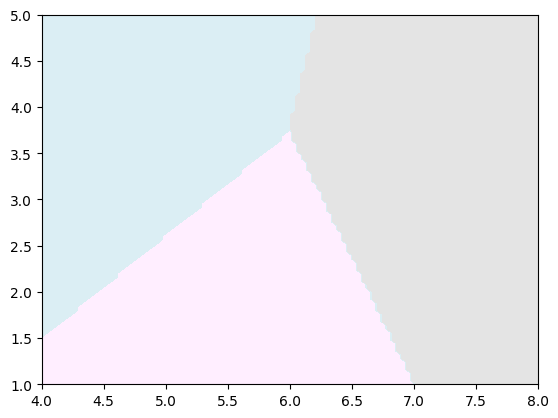

In [20]:
fig, ax = plt.subplots()

# 根据每个点的预测的标签绘制对应的区域
ax.contourf(xx1, xx2, Z, cmap=cmap_light) #用填充等高线可视化聚类区域。


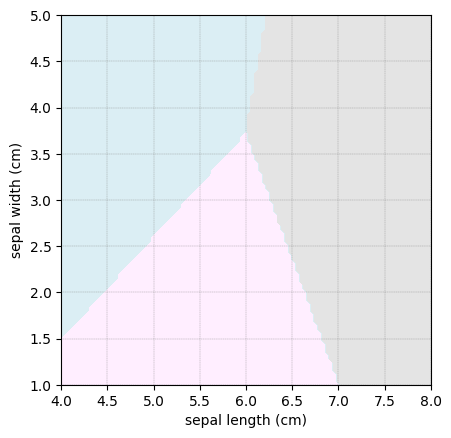

In [21]:
fig, ax = plt.subplots()

# 根据每个点的预测的标签绘制对应的区域
ax.contourf(xx1, xx2, Z, cmap=cmap_light) #用填充等高线可视化聚类区域。
ax.set_xlim(4, 8); ax.set_ylim(1, 5) # 范围
ax.set_xlabel(iris.feature_names[0]) # 标签
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  #网格属性
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致

##绘制原始数据的散点图

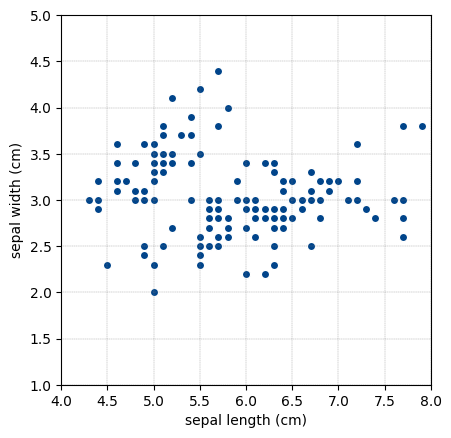

In [24]:
# 原始数据
fig, ax = plt.subplots()
ax.scatter(x=X[:, 0], y=X[:, 1],
           color=np.array([0, 68, 138])/255.,
           alpha=1.0,
           linewidth = 1, edgecolor=[1,1,1]) #边界颜色为白色
ax.set_xlim(4, 8); ax.set_ylim(1, 5) # 范围
ax.set_xlabel(iris.feature_names[0]) # 标签
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  #网格属性
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致

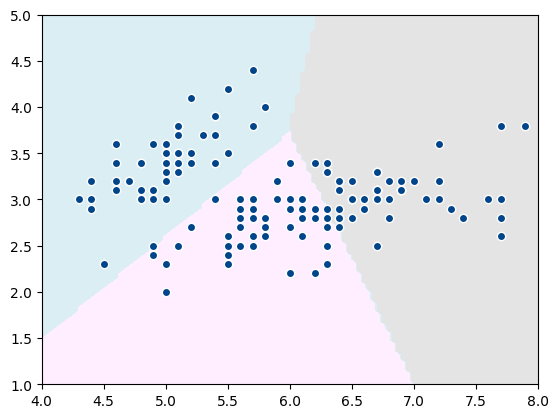

In [25]:
fig, ax = plt.subplots()
ax.contourf(xx1, xx2, Z, cmap=cmap_light)
ax.scatter(x=X[:, 0], y=X[:, 1],
 color=np.array([0, 68, 138])/255.,
 alpha=1.0,
 linewidth = 1, edgecolor=[1,1,1])


## 绘制决策边界

levels: [0, 1, 2]


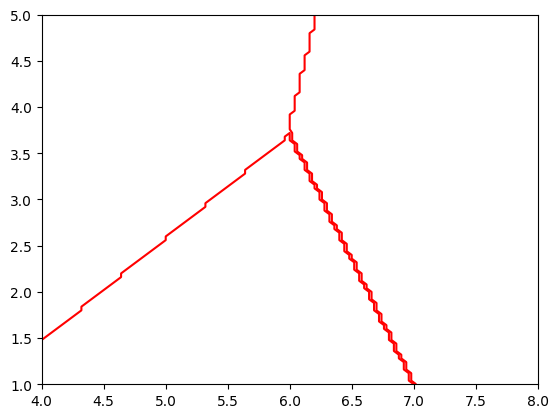

In [26]:

# 绘制决策边界
fig, ax = plt.subplots()
levels = np.unique(Z).tolist(); # 去重并转为list；判断有几个类别
print(f"levels: {levels}")
# 绘制边界也就是等高线；3个种类
ax.contour(xx1, xx2, Z, levels=levels,colors='r')

##获取 KMeans 聚类算法拟合后得到的聚类质心的坐标。

*   列表项
*   列表项



centroids: [[5.8        2.7       ]
 [5.00392157 3.40980392]
 [6.82391304 3.07826087]]


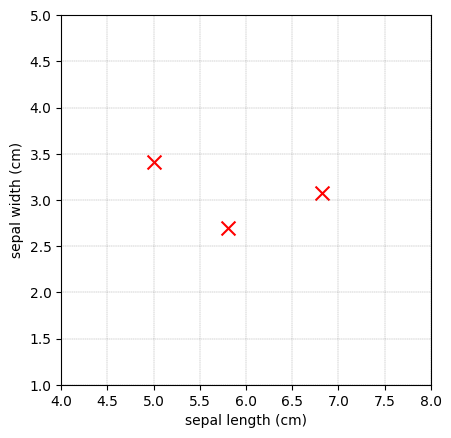

In [27]:

#获取 KMeans 聚类算法拟合后得到的聚类质心的坐标。
fig, ax = plt.subplots()
centroids = kmeans.cluster_centers_
print(f"centroids: {centroids}")
#绘制质心；类似多行2列的数组；每一行就是一个质心
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker="x", s=100, linewidths=1.5,
           color="r")

ax.set_xlim(4, 8); ax.set_ylim(1, 5) # 范围
ax.set_xlabel(iris.feature_names[0]) # 标签
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  #网格属性
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致

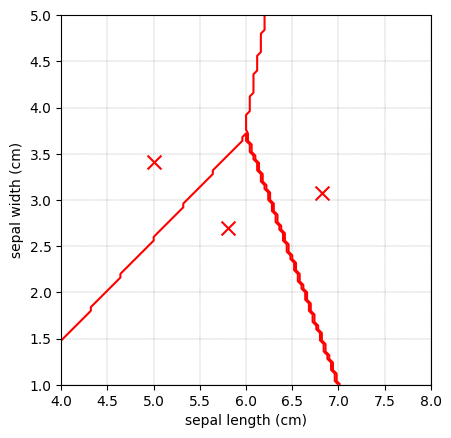

In [29]:
# 绘制决策边界
fig, ax = plt.subplots()
levels = np.unique(Z).tolist();
ax.contour(xx1, xx2, Z, levels=levels,colors='r')
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
 marker="x", s=100, linewidths=1.5,
 color="r")
ax.set_xlim(4, 8); ax.set_ylim(1, 5)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,
 color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')
